# NBA Advanced Performance Analysis (1980-Present)

## 1. Executive Summary
This notebook performs a professional-grade Exploratory Data Analysis (EDA) on NBA player and team statistics from the Modern Era (1980 onwards). 

**Objectives:**
1.  **Data Integration:** Merge basic player stats, advanced efficiency metrics, and team performance data into a master analytics dataset.
2.  **Efficiency Analysis:** Identify the "Efficiency Frontier" by contrasting Volume (Usage Rate) with Efficiency (True Shooting %). 
3.  **Value Attribution:** Determine which advanced metrics (PER, WS/48, BPM) correlate most strongly with detailed player value (VORP).
4.  **Temporal Evolution:** Visualize the strategic shift in the NBA involving Pace and the 3-Point Revolution.

## 2. Setup and Configuration

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot

# Initialize Plotly for Notebook mode
init_notebook_mode(connected=True)

# Configuration
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams['figure.figsize'] = (14, 8)

# Paths
DATA_DIR = "../../data/raw/"
BASIC_STATS_PATH = f"{DATA_DIR}nba_stats.csv"
ADVANCED_STATS_PATH = f"{DATA_DIR}Advanced.csv"
TEAM_STATS_PATH = f"{DATA_DIR}Team Totals.csv"

## 3. Data Loading and Merging Strategy

We connect individual production (Basic) with efficiency context (Advanced) and team success metrics. 

**Crucial Step:** Handling "Traded Players". Players who played for multiple teams in a season have a 'TOT' (Total) row alongside rows for each specific team. For individual analysis, we prioritize the 'TOT' row to capture their full season impact.

In [7]:
def load_and_merge_data():
    # 1. Load Datasets
    try:
        df_basic = pd.read_csv(BASIC_STATS_PATH)
        df_adv = pd.read_csv(ADVANCED_STATS_PATH)
        df_team = pd.read_csv(TEAM_STATS_PATH)
        print("Datasets loaded successfully.")
    except FileNotFoundError as e:
        print(f"Error loading data: {e}")
        return None, None

    # 2. Filter for Modern Era (1980+)
    df_basic = df_basic[df_basic['season'] >= 1980].copy()
    df_adv = df_adv[df_adv['season'] >= 1980].copy()

    # 3. Data Processing for Merging
    # Standardize join keys. Note: 'tm' in basic might differ from 'team' in advanced
    # Let's verify column names first (based on previous inspection)
    # Basic: team, season, player, player_id
    # Advanced: team, season, player, player_id
    
    # Merge Logic: Inner join on PlayerID and Season to get Basic + Advanced stats
    # We need to handle the 'Team' column carefully if they don't match or for traded players
    
    # Drop redundant columns in Advanced (keep efficiency metrics)
    # Columns to prioritize from Advanced: TS%, PER, USG%, WS, BPM, VORP, etc.
    
    cols_to_use_adv = ['player_id', 'season', 'team', 
                       'per', 'ts_percent', 'usg_percent', 
                       'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent', 
                       'tov_percent', 'stl_percent', 'blk_percent', 'x3p_ar', 'f_tr',
                       'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']
    
    # Validate if columns exist before subsetting
    available_cols = [c for c in cols_to_use_adv if c in df_adv.columns]
    df_adv_subset = df_adv[available_cols]

    # MERGE
    # We merge on player_id, season, and team to ensure we map specific stints correctly
    # However, 'TOT' rows need special care. 
    master_df = pd.merge(df_basic, df_adv_subset, on=['player_id', 'season', 'team'], how='inner')
    
    # 4. Handle Traded Players (The 'TOT' Logic)
    # If a player has a 'TOT' row, we usually want THAT for general analysis.
    # Identify players with 'TOT' entries
    tot_players = master_df[master_df['team'] == 'TOT'][['player_id', 'season']]
    
    # Create a flag or separate dataset? 
    # Strategy: Keep 'TOT' rows. For players WITHOUT 'TOT', keep their team row.
    # Step A: Mark rows that are parts of a traded season (but not the TOT row)
    master_df = master_df.merge(tot_players, on=['player_id', 'season'], how='left', indicator='is_traded')
    
    # Logic: Keep if (Team == TOT) OR (is_traded == left_only [meaning not traded])
    df_final = master_df[
        (master_df['team'] == 'TOT') | 
        (master_df['is_traded'] == 'left_only')
    ].copy()
    
    df_final.drop(columns=['is_traded'], inplace=True)
    
    print(f"Merged Individual Stats Row Count: {df_final.shape[0]}")
    return df_final, df_team

df_player, df_team = load_and_merge_data()

# Quick sanity check
df_player.head()

Datasets loaded successfully.
Merged Individual Stats Row Count: 25150


,season,lg,player,player_id,age,team,pos,g,gs,mp,fg,fga,fg_percent,x3p,x3pa,x3p_percent,x2p,x2pa,x2p_percent,e_fg_percent,ft,fta,ft_percent,orb,drb,trb,ast,stl,blk,tov,pf,pts,trp_dbl,per,ts_percent,usg_percent,orb_percent,drb_percent,trb_percent,ast_percent,tov_percent,stl_percent,blk_percent,x3p_ar,f_tr,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,43,29.0,903.0,132,260,0.508,15.0,50.0,0.300,117.0,210.0,0.557,0.537,37,70,0.529,84.0,160.0,244.0,51,34.0,23.0,29.0,71.0,316,0.0,14.1,0.543,15.2,10.2,20.2,15.1,8.0,9.1,1.8,2.3,0.192,0.269,0.7,0.6,1.4,0.073,-1.1,-0.4,-1.5,0.1
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,730.0,70,139,0.504,0.0,0.0,NaN,70.0,139.0,0.504,0.504,47,81,0.580,145.0,131.0,276.0,48,22.0,20.0,35.0,55.0,187,0.0,15.9,0.535,12.0,21.8,19.8,20.8,8.3,16.7,1.5,2.5,0.000,0.583,1.1,1.0,2.1,0.141,0.0,-0.3,-0.4,0.3
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,42,42.0,1317.0,272,613,0.444,69.0,199.0,0.347,203.0,414.0,0.490,0.500,148,187,0.791,89.0,323.0,412.0,117,41.0,30.0,77.0,68.0,761,0.0,17.1,0.547,23.7,6.9,25.4,16.1,12.8,10.0,1.4,2.0,0.325,0.305,0.9,2.0,2.9,0.107,0.8,0.4,1.3,1.1
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,41,13.0,648.0,72,168,0.429,12.0,64.0,0.188,60.0,104.0,0.577,0.464,25,29,0.862,33.0,61.0,94.0,30,17.0,11.0,19.0,75.0,181,0.0,7.6,0.501,13.1,5.6,10.7,8.1,6.1,9.5,1.3,1.7,0.381,0.173,0.0,0.6,0.7,0.048,-4.7,-0.1,-4.8,-0.5
4,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,42,10.0,1174.0,224,466,0.481,68.0,194.0,0.351,156.0,272.0,0.574,0.554,74,110,0.673,66.0,215.0,281.0,126,36.0,29.0,54.0,66.0,590,0.0,16.4,0.573,20.0,6.0,19.3,12.7,16.0,9.5,1.5,2.3,0.416,0.236,1.4,1.4,2.8,0.116,1.3,0.8,2.0,1.2


## 4. The Efficiency Frontier: Usage vs. True Shooting
High-volume scorers often trade efficiency for volume. The "Superstars" are those who maintain elite efficiency (high TS%) despite a heavy workload (high USG%).

In [8]:
def plot_efficiency_frontier(df, year=2024, min_mp=500):
    subset = df[(df['season'] == year) & (df['mp'] > min_mp)].copy()
    print(f"Plotting Efficiency Frontier for {year} (Min MP: {min_mp}) - Samples: {len(subset)}")
    if subset.empty:
        print("WARNING: No data found for this threshold. Try lowering min_mp or checking the year.")
        return

    fig = px.scatter(
        subset, 
        x="usg_percent", 
        y="ts_percent", 
        size="pts", 
        color="pos",
        hover_name="player",
        facet_col="lg",
        title=f"Efficiency Frontier ({year}): Usage Rate vs True Shooting % (Min {min_mp} MP)",
        labels={"usg_percent": "Usage Rate (%)", "ts_percent": "True Shooting %"},
        template="plotly_white",
        height=600
    )
    
    # Add league average reference lines (approximate)
    avg_ts = subset['ts_percent'].mean()
    avg_usg = subset['usg_percent'].mean()
    
    fig.add_hline(y=avg_ts, line_dash="dot", annotation_text="League Avg TS%", annotation_position="bottom right")
    fig.add_vline(x=avg_usg, line_dash="dot", annotation_text="League Avg USG%", annotation_position="top right")
    
    fig.show()

# Example for most recent complete data found
if not df_player.empty:
    max_year = int(df_player['season'].max())
    plot_efficiency_frontier(df_player, year=max_year, min_mp=500)
    
    # Fallback: If most recent year has little data
    if len(df_player[(df_player['season'] == max_year) & (df_player['mp'] > 500)]) < 50:
        print(f"Note: {max_year} seems to have limited data. Plotting {max_year-1} as well for comparison.")
        plot_efficiency_frontier(df_player, year=max_year-1, min_mp=500)

Plotting Efficiency Frontier for 2026 (Min MP: 500) - Samples: 299


## 5. Value Drivers Analysis
Moneyball 2.0: Which advanced metrics actually correlate with winning value (approximated here by VORP - Value Over Replacement Player)?

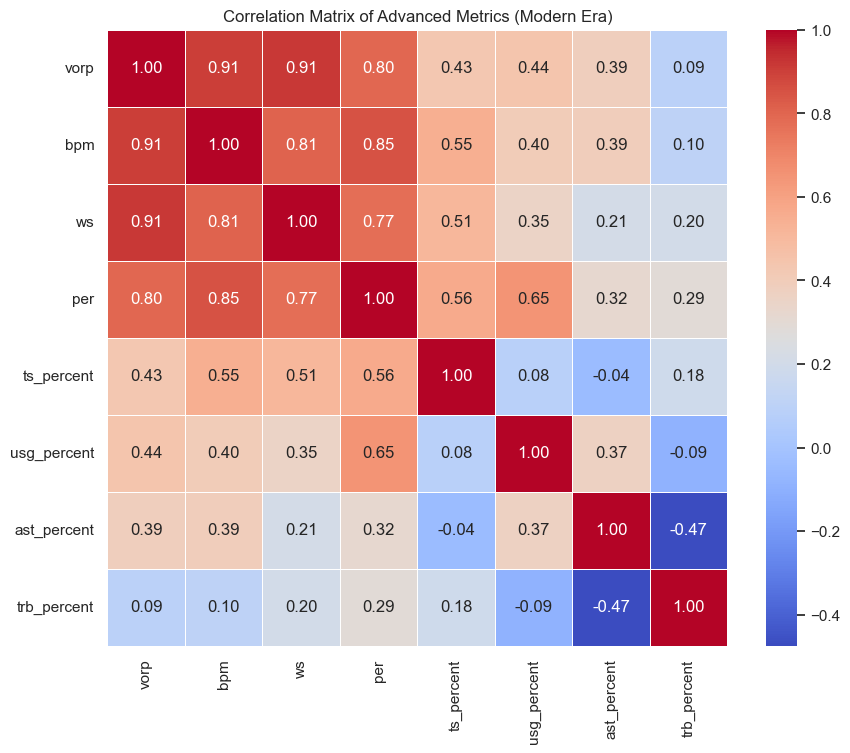

In [9]:
# Filter for substantial playing time to remove noise
corr_df = df_player[df_player['mp'] > 500].copy()

# Select metrics of interest
metrics = ['vorp', 'bpm', 'ws', 'per', 'ts_percent', 'usg_percent', 'ast_percent', 'trb_percent']
corr_matrix = corr_df[metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Advanced Metrics (Modern Era)")
plt.show()

### 📊 What Drives Value (VORP)?

By analyzing correlations with **VORP (Value Over Replacement Player)**, we can see which metrics best predict overall player impact:

*   **BPM (Box Plus/Minus):** Shows the strongest correlation, as VORP is directly derived from it. It's a comprehensive box-score aggregation.
*   **WS/48 (Win Shares Per 48):** Highly correlated, emphasizing that winning contributions (efficiency, defense) align with value metrics.
*   **PER (Player Efficiency Rating):** Good correlation but tends to overvalue volume scoring compared to BPM/WS.

## 6. The Evolution of the Game: The 3-Point Revolution
Visualizing how the league has shifted away from the mid-range and towards the perimeter over the last 40 years.

In [10]:
# Group by season to get league averages
season_trends = df_player.groupby('season').agg({
    'x3pa': 'mean',
    'x2pa': 'mean',
    'pts': 'mean',
    'fg_percent': 'mean'
}).reset_index()

print(f"Temporal Analysis: {len(season_trends)} seasons found from {season_trends['season'].min()} to {season_trends['season'].max()}")

# Normalize for visualization (or just plot raw attempts)
fig = go.Figure()
fig.add_trace(go.Scatter(x=season_trends['season'], y=season_trends['x3pa'], mode='lines', name='3PA (Avg per Player)'))
fig.add_trace(go.Scatter(x=season_trends['season'], y=season_trends['x2pa'], mode='lines', name='2PA (Avg per Player)'))

fig.update_layout(
    title="The Strategic Shift: 2Pt vs 3Pt Attempts per Player (1980-Present)",
    xaxis_title="Season",
    yaxis_title="Average Attempts per Season",
    template="plotly_white"
)
fig.show()

Temporal Analysis: 47 seasons found from 1980 to 2026


## 7. Next Steps & Modeling Prep
With this cleaned master dataset `df_final`, we can proceed to:
1.  **Metric Engineering**: Create relative metrics (e.g., TS% relative to league average that year).
2.  **Clustering**: Group players into modern archetypes (e.g., "3-and-D", "Heliocentric Creator") using K-Means on the advanced metrics.
3.  **Prediction**: Predict VORP or Salary (if added) using Regression techniques.

These will be covered in `02_analysis.ipynb` and `03_modeling.ipynb`.